**Cellule 1 : Chargement et préparation des données**

In [15]:
#importation les bibliothéques nécessaires
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
# 1. Chargement des données
df = pd.read_csv("../data/linkedin_cleaned_data.csv")

In [5]:
# 2. Sélection des colonnes pour la similarité
# On s'assure que toutes les colonnes sont des chaînes de caractères pour la comparaison
cols_sim = ['current_company_name', 'city', 'country_code', 'industry', 'educations_details']
for col in cols_sim:
    df[col] = df[col].fillna("Inconnu").astype(str)

In [6]:
# On garde les IDs et les noms pour les labels
employes_ids = df['id'].tolist()
employes_noms = df['name'].tolist()

print(f"✅ Données prêtes pour {len(employes_ids)} employés.")

✅ Données prêtes pour 1000 employés.


**Cellule 2 : Calcul de la Matrice de Similarité et d'Adjacence**

In [8]:
n = len(df)
# Initialisation de la matrice d'adjacence avec des zéros
adj_matrix = np.zeros((n, n), dtype=int)

In [9]:
# Poids définis par votre stratégie
w = {
    'company': 3,
    'city': 2,
    'country': 1,
    'industry': 2,
    'education': 2
}

In [10]:
# On parcourt chaque paire d'employés (i, j)
# On utilise une boucle optimisée pour ne calculer que la moitié de la matrice (symétrie)
data_values = df[cols_sim].values

for i in range(n):
    for j in range(i + 1, n):
        score = 0
        # Comparaison de chaque attribut
        if data_values[i, 0] == data_values[j, 0]: score += w['company']
        if data_values[i, 1] == data_values[j, 1]: score += w['city']
        if data_values[i, 2] == data_values[j, 2]: score += w['country']
        if data_values[i, 3] == data_values[j, 3]: score += w['industry']
        if data_values[i, 4] == data_values[j, 4]: score += w['education']
        
        # Application du seuil de 3
        if score >= 3:
            adj_matrix[i, j] = 1
            adj_matrix[j, i] = 1

print("✅ Matrice d'adjacence construite.")

✅ Matrice d'adjacence construite.


In [12]:
#Afficher le matrice
print(adj_matrix)

[[0 0 0 ... 1 1 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [1 0 0 ... 0 1 0]
 [1 0 0 ... 1 0 1]
 [0 0 0 ... 0 1 0]]


**Cellule 3 : Sauvegarde de la matrice**

In [13]:
# Conversion en DataFrame pour la sauvegarde
df_adj = pd.DataFrame(adj_matrix, index=employes_ids, columns=employes_ids)

# Sauvegarde en CSV
chemin_adj = "../resultats/matrice_adjacence_employees.csv"
df_adj.to_csv(chemin_adj)

print(f"💾 Matrice d'adjacence sauvegardée dans : {chemin_adj}")

💾 Matrice d'adjacence sauvegardée dans : ../resultats/matrice_adjacence_employees.csv


**Cellule 4 : Construction et Analyse du Graphe "Employees"**

In [18]:
# --- 1. PRÉPARATION DU GRAPHE COMPLET ---
# On crée le graphe à partir de la matrice d'adjacence
G_emp = nx.from_numpy_array(adj_matrix)

In [19]:
# On associe les bons identifiants et les vrais noms aux nœuds
mapping = {i: emp_id for i, emp_id in enumerate(employes_ids)}
G_emp = nx.relabel_nodes(G_emp, mapping)

nom_attr = {emp_id: nom for emp_id, nom in zip(employes_ids, employes_noms)}
nx.set_node_attributes(G_emp, nom_attr, 'name')

In [20]:
# --- 2. CRÉATION DE L'ÉCHANTILLON POUR L'AFFICHAGE ---
taille_echantillon = 80
echantillon_ids = random.sample(employes_ids, taille_echantillon)
sous_graphe_emp = G_emp.subgraph(echantillon_ids).copy()

In [21]:
# On nettoie l'image en retirant les employés qui n'ont aucun lien dans cet échantillon
noeuds_isoles = [n for n, d in sous_graphe_emp.degree() if d == 0]
sous_graphe_emp.remove_nodes_from(noeuds_isoles)

✅ L'image a été générée et sauvegardée avec succès dans : ../resultats/graphe_similarite_employees.png


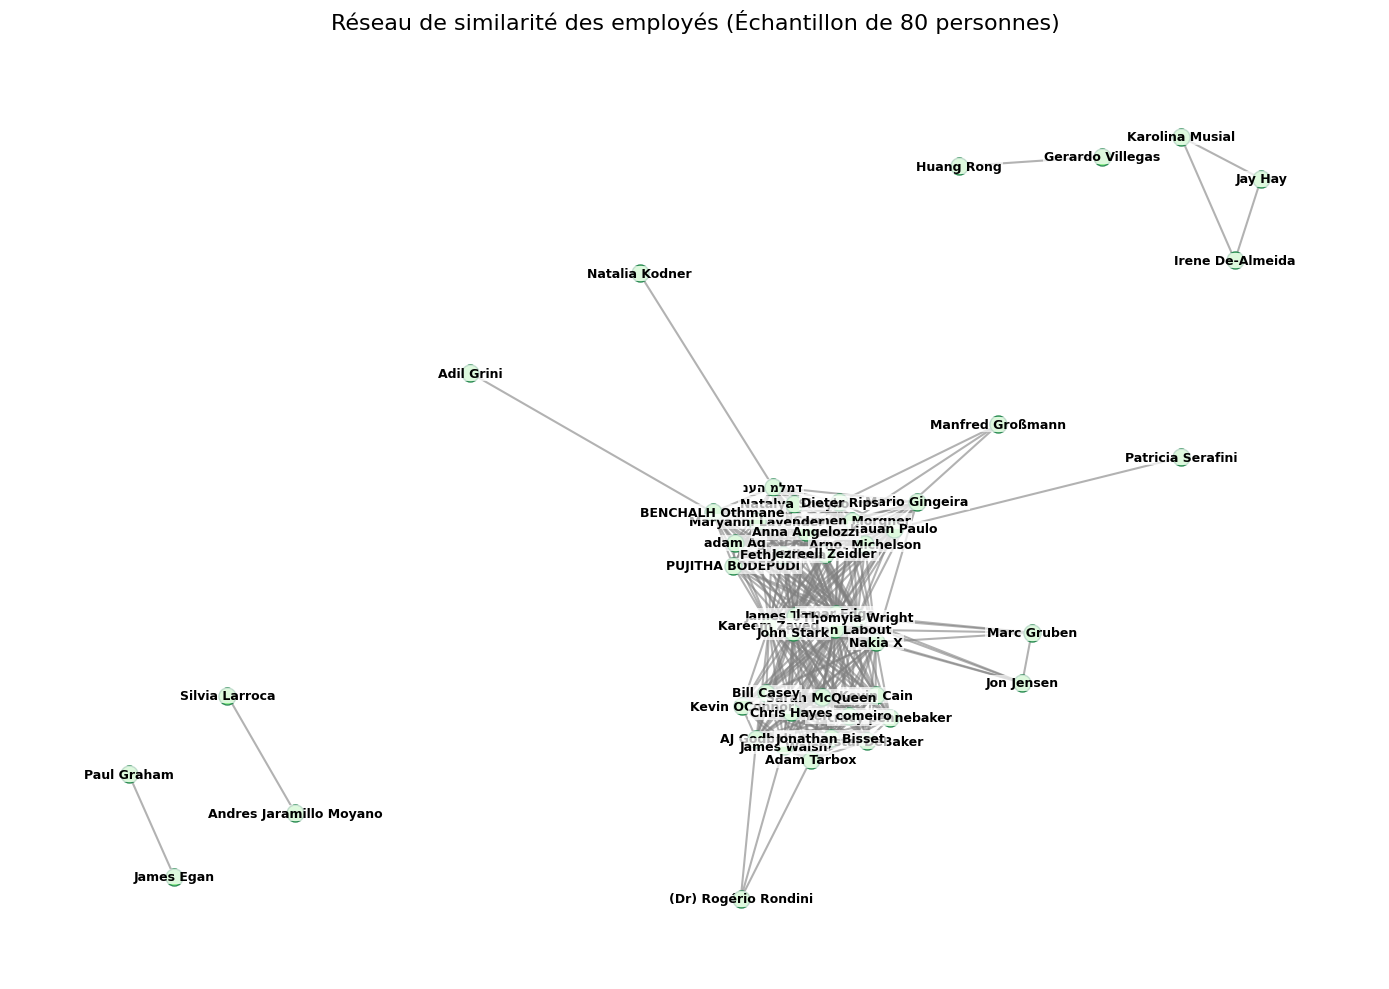

In [22]:
# --- 3. DESSIN ET SAUVEGARDE DU GRAPHE ---
plt.figure(figsize=(14, 10))

# Disposition optimisée pour bien voir les groupes (cliques)
pos = nx.spring_layout(sous_graphe_emp, k=0.4, iterations=50, seed=42)
labels_noms = {node: sous_graphe_emp.nodes[node]['name'] for node in sous_graphe_emp.nodes()}

# Dessin des composants (nœuds, lignes, et textes)
nx.draw_networkx_nodes(sous_graphe_emp, pos, node_color='lightgreen', edgecolors='seagreen', node_size=150)
nx.draw_networkx_edges(sous_graphe_emp, pos, alpha=0.6, edge_color='gray', width=1.5)
nx.draw_networkx_labels(sous_graphe_emp, pos, labels_noms, font_size=9, font_weight='bold',
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=1))

# Finitions (Titre, suppression des axes)
plt.title(f"Réseau de similarité des employés (Échantillon de {taille_echantillon} personnes)", fontsize=16, pad=20)
plt.axis('off')
plt.tight_layout()

# Sauvegarde de l'image en haute qualité (HD)
chemin_image_emp = "../resultats/graphe_similarite_employees.png"
plt.savefig(chemin_image_emp, dpi=300, bbox_inches='tight')
print(f"✅ L'image a été générée et sauvegardée avec succès dans : {chemin_image_emp}")

# Affichage du résultat juste en dessous dans le notebook
plt.show()

**Analyse le graphe**

In [23]:
# --- 1. CALCUL DES MESURES GLOBALES ---
densite_emp = nx.density(G_emp)
clustering_global = nx.average_clustering(G_emp)

In [24]:
# --- 2. CALCUL DES MESURES LOCALES ---
degres = dict(G_emp.degree())
deg_centrality = nx.degree_centrality(G_emp)
bet_centrality = nx.betweenness_centrality(G_emp) # C'est le calcul le plus lourd
clustering_local = nx.clustering(G_emp)

In [25]:
# --- 3. ORGANISATION DANS UN DATAFRAME ---
df_mesures_emp = pd.DataFrame({
    'ID_Employe': list(G_emp.nodes()),
    'Nom': [G_emp.nodes[n].get('name', 'Inconnu') for n in G_emp.nodes()],
    'Degre': [degres[n] for n in G_emp.nodes()],
    'Centralite_Degre': [deg_centrality[n] for n in G_emp.nodes()],
    'Betweenness_Centrality': [bet_centrality[n] for n in G_emp.nodes()],
    'Coefficient_Clustering': [clustering_local[n] for n in G_emp.nodes()]
})

In [26]:
# --- 4. AFFICHAGE DES RÉSULTATS ---
print("\n" + "="*40)
print("📊 MESURES STRUCTURELLES GLOBALES")
print("="*40)
print(f"Densité du réseau : {densite_emp:.5f}")
print(f"Coefficient de clustering moyen : {clustering_global:.5f}")

print("\n" + "="*40)
print("🏆 TOP 5 : DEGRÉ DE CENTRALITÉ (Les plus connectés)")
print("="*40)
top_degres = df_mesures_emp.sort_values(by='Centralite_Degre', ascending=False).head(5)
print(top_degres[['Nom', 'Degre', 'Centralite_Degre']].to_string(index=False))

print("\n" + "="*40)
print("🌉 TOP 5 : BETWEENNESS CENTRALITY (Les ponts entre les groupes)")
print("="*40)
top_betweenness = df_mesures_emp.sort_values(by='Betweenness_Centrality', ascending=False).head(5)
print(top_betweenness[['Nom', 'Betweenness_Centrality', 'Coefficient_Clustering']].to_string(index=False))


📊 MESURES STRUCTURELLES GLOBALES
Densité du réseau : 0.10429
Coefficient de clustering moyen : 0.68308

🏆 TOP 5 : DEGRÉ DE CENTRALITÉ (Les plus connectés)
              Nom  Degre  Centralite_Degre
   Randy Holliday    447          0.447447
        Mike Holt    425          0.425425
Matthew McIlvenna    425          0.425425
     Sonya Paxton    425          0.425425
 Teunis Westbroek    425          0.425425

🌉 TOP 5 : BETWEENNESS CENTRALITY (Les ponts entre les groupes)
                                Nom  Betweenness_Centrality  Coefficient_Clustering
                      Gary Fallowes                0.020317                0.988166
Christina Murdzek MHS, M(ASCP), CIC                0.018691                0.818182
                     Selim Amuroglu                0.016646                0.916434
                     Randy Holliday                0.015813                0.485950
                  Carla Al Ahmadieh                0.013480                0.714286


In [27]:
# --- 5. SAUVEGARDE DES RÉSULTATS ---
# A. Sauvegarde de toutes les mesures locales en CSV
chemin_csv = "../resultats/mesures_completes_employees.csv"
df_mesures_emp.to_csv(chemin_csv, index=False, encoding='utf-8')

# B. Sauvegarde du rapport texte
chemin_txt = "../resultats/rapport_analyse_employees.txt"
with open(chemin_txt, "w", encoding="utf-8") as f:
    f.write("=== ANALYSE DU RÉSEAU DES EMPLOYÉS ===\n\n")
    f.write(f"Densité du réseau : {densite_emp:.5f}\n")
    f.write(f"Coefficient de clustering moyen : {clustering_global:.5f}\n\n")
    f.write("=== TOP 10 DES EMPLOYÉS PAR DEGRÉ ===\n")
    f.write(df_mesures_emp.sort_values(by='Degre', ascending=False).head(10)[['Nom', 'Degre', 'Centralite_Degre']].to_string(index=False))
    f.write("\n\n=== TOP 10 DES EMPLOYÉS PAR BETWEENNESS CENTRALITY ===\n")
    f.write(df_mesures_emp.sort_values(by='Betweenness_Centrality', ascending=False).head(10)[['Nom', 'Betweenness_Centrality']].to_string(index=False))

# C. Création et sauvegarde de la distribution des degrés
plt.figure(figsize=(10, 6))
plt.hist(df_mesures_emp['Degre'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution des degrés des employés", fontsize=14)
plt.xlabel("Degré (Nombre de liens de similarité)", fontsize=12)
plt.ylabel("Fréquence (Nombre d'employés)", fontsize=12)
plt.grid(axis='y', alpha=0.7)

chemin_dist = "../resultats/distribution_degres_employees.png"
plt.savefig(chemin_dist, dpi=300, bbox_inches='tight')
plt.close() # On ferme le plot car le but ici est juste de le sauvegarder

print("\n✅ Tous les résultats ont été sauvegardés avec succès dans le dossier 'resultats' :")
print(f"- {chemin_csv}")
print(f"- {chemin_txt}")
print(f"- {chemin_dist}")


✅ Tous les résultats ont été sauvegardés avec succès dans le dossier 'resultats' :
- ../resultats/mesures_completes_employees.csv
- ../resultats/rapport_analyse_employees.txt
- ../resultats/distribution_degres_employees.png
